## DRW - Crypto Market Prediction
### Develop a model capable of predicting crypto future price movements

### Description
The cryptocurrency market represents one of the most dynamic and rapidly evolving financial landscapes, offering a wealth of opportunities for those who can extract meaningful insights from its vast streams of data. However, market information in crypto has an inherently low signal-to-noise ratio making it exceptionally difficult to identify predictive patterns. Price movements are shaped by a complex interplay of liquidity, order flow dynamics, sentiment shifts, and structural inefficiencies, requiring sophisticated quantitative techniques to decode.

At DRW, we have been at the forefront of financial innovation for over three decades, embracing cutting-edge technology and rigorous quantitative research to optimize trading strategies. Through Cumberland, our dedicated crypto trading arm, we were among the earliest institutional participants in the digital asset space, helping to shape market structure and improve efficiency. As one of the largest liquidity providers in crypto, we thrive on developing proprietary trading strategies that adapt to the ever-changing market environment.

In this competition, we invite you to build a model capable of predicting short-term crypto future price movements using our production feature data alongside publicly available market volume statistics. The proprietary production features we provide are integral to our trading strategies, capturing subtle market signals that help us navigate and seize opportunities in real time. Moreover, these production features, combined with public data describing the broader market state, create a rich and challenging dataset for data mining and modeling. Your task is to integrate these diverse sources of information into a single directional signal that effectively predicts crypto future price movements.

Through this challenge, we aim to replicate the real-world problems we tackle at DRW every day—leveraging advanced machine learning techniques to extract structure from noisy, high-dimensional market data. The most successful solutions will provide a learning model that efficiently incorporates both explicit patterns and implicit interactions between all data features to refine price movement predictions.

We look forward to seeing how the Kaggle community approaches this problem and how different modeling techniques can enhance our understanding of market dynamics. If you're excited by complex, high-impact challenges beyond predictive modeling, DRW offers a diverse range of opportunities at the intersection of quantitative research, technology, and trading strategy development.

### Tips
1. The training dataset covers the period from March 1, 2023, to February 29, 2024. The test data comes after the training period, though its timestamps are masked. Since data relevance matters, you don’t have to use the entire training set—feel free to focus on a specific window, such as only the most recent months, if that works better for your model.

2. You’re welcome to use all the data we provide, as well as any freely and publicly available external datasets—including pre-trained models—to support your analysis and solution development.

3. Efforts in this competition can be directed toward two key aspects:

- Data Exploration and Feature Analysis - Understanding the characteristics of the anonymized proprietary features and extracting meaningful insights from public market data through data mining and statistical analysis.
- Advanced Modeling Techniques - Developing machine learning models that effectively select, capture and integrate as much information as possible from all the available features.

### train.parquet
The training dataset containing all historical market data along with the corresponding labels.

- timestamp: The timestamp index representing the minute associated with each row.
- bid_qty: The total quantity buyers are willing to purchase at the best (highest) bid price at the given timestamp.
- ask_qty: The total quantity sellers are offering to sell at the best (lowest) ask price at the given timestamp.
- buy_qty: The total trading quantity executed at the best ask price during the given minute.
- sell_qty: The total trading quantity executed at the best bid price during the given minute.
- volume: The total traded volume during the minute.
- X_{1,...,780}: A set of anonymized market features derived from proprietary data sources.
- label: The target variable representing the anonymized market price movement to be predicted.


### test.parquet
The test dataset has the same feature structure as train.parquet, with the following differences:

- timestamp: To prevent future peeking, all timestamps are masked, shuffled, and replaced with a unique ID.
- label: All labels in the test set are set to 0.


In [2]:
import pandas as pd

train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")
train.head()

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X772,X773,X774,X775,X776,X777,X778,X779,X780,label
2023-03-01 00:00:00,15.283,8.425,176.405,44.984,221.389,0.181844,-0.637860,0.006652,0.136870,0.116698,...,0.333753,-0.009992,-0.695595,-0.444077,-0.191238,-0.184251,-0.471897,-0.625428,-0.553991,0.562539
2023-03-01 00:01:00,38.590,2.336,525.846,321.950,847.796,0.489497,-0.075619,0.431594,0.522400,0.475255,...,0.333657,-0.010040,-0.696226,-0.452866,-0.200082,-0.188929,-0.472842,-0.625832,-0.554426,0.533686
2023-03-01 00:02:00,0.442,60.250,159.227,136.369,295.596,0.260121,-0.444684,0.100695,0.224729,0.203282,...,0.333667,-0.010037,-0.696832,-0.461383,-0.208786,-0.193571,-0.473785,-0.626236,-0.554860,0.546505
2023-03-01 00:03:00,4.865,21.016,335.742,124.963,460.705,0.099976,-0.666728,-0.123858,0.019197,0.014459,...,0.333174,-0.010279,-0.697391,-0.469628,-0.217350,-0.198175,-0.474726,-0.626639,-0.555294,0.357703
2023-03-01 00:04:00,27.158,3.451,98.411,44.407,142.818,0.270893,-0.325973,0.116336,0.234311,0.214073,...,0.333171,-0.010283,-0.697940,-0.477622,-0.225780,-0.202745,-0.475666,-0.627043,-0.555728,0.362452


In [3]:
test.head()

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X772,X773,X774,X775,X776,X777,X778,X779,X780,label
ID,,,,,,,,,,,,,,,,,,,,,
1,0.317,8.102,13.164,10.272,23.436,-0.341229,0.041851,-0.020094,-0.206221,-0.297124,...,-0.147911,-0.043417,1.521787,1.548965,1.495735,1.166730,0.281056,-0.187831,-0.599553,0
2,2.608,2.111,123.562,40.163,163.725,-1.029564,-1.382505,-1.214935,-1.020241,-0.960397,...,-0.126703,-0.077090,-0.703054,-0.716951,-0.721292,-0.674619,-0.639318,-0.736268,-0.862220,0
3,2.768,10.787,126.137,118.266,244.403,-2.594090,-5.486158,-4.744466,-3.930152,-3.275324,...,-0.147750,-0.030627,-0.703514,-0.717525,-0.731701,-0.750998,-0.789366,-0.850941,-1.033131,0
4,0.948,12.157,16.069,31.723,47.792,0.240745,0.997585,1.028965,1.081052,0.811895,...,-0.136737,-0.033380,1.521167,1.551771,1.582833,1.625830,1.762155,1.911924,1.962445,0
5,1.084,3.493,32.679,37.327,70.006,0.067189,0.772852,0.772152,0.714846,0.514422,...,-0.218991,-0.004915,-0.703161,-0.716900,-0.714699,-0.652209,-0.623165,-0.699887,-0.640094,0


In [4]:
sample_submission = pd.read_csv("sample_submission.csv")
sample_submission.head()

,ID,prediction
0,1,-0.280233
1,2,1.371969
2,3,-2.045252
3,4,-1.447555
4,5,-1.303901


In [5]:
def reduce_mem_usage(dataframe, dataset):    
    print('Reducing memory usage for:', dataset)
    initial_mem_usage = dataframe.memory_usage().sum() / 1024**2
    
    for col in dataframe.columns:
        col_type = dataframe[col].dtype

        c_min = dataframe[col].min()
        c_max = dataframe[col].max()
        if str(col_type)[:3] == 'int':
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                dataframe[col] = dataframe[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                dataframe[col] = dataframe[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                dataframe[col] = dataframe[col].astype(np.int32)
            elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                dataframe[col] = dataframe[col].astype(np.int64)
        else:
            if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                dataframe[col] = dataframe[col].astype(np.float16)
            elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                dataframe[col] = dataframe[col].astype(np.float32)
            else:
                dataframe[col] = dataframe[col].astype(np.float64)

    final_mem_usage = dataframe.memory_usage().sum() / 1024**2
    print('--- Memory usage before: {:.2f} MB'.format(initial_mem_usage))
    print('--- Memory usage after: {:.2f} MB'.format(final_mem_usage))
    print('--- Decreased memory usage by {:.1f}%\n'.format(100 * (initial_mem_usage - final_mem_usage) / initial_mem_usage))

    return dataframe

In [6]:
#train = reduce_mem_usage(train, "train")
#test = reduce_mem_usage(test, "test")

## EDA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['figure.figsize'] = (12, 4)
sns.set_theme(style='darkgrid')

# --- Basic shape & dtypes ---
print(f"Train shape: {train.shape}")
print(f"Date range:  {train.index.min()} → {train.index.max()}")
print(f"Missing values: {train.isnull().sum().sum()}")
print(f"Test shape: {test.shape}")
print(f"Missing values: {test.isnull().sum().sum()}")

Train shape: (525886, 786)
Date range:  2023-03-01 00:00:00 → 2024-02-29 23:59:00
Missing values: 0
Test shape: (538150, 786)
Missing values: 0


### 1. Label distribution

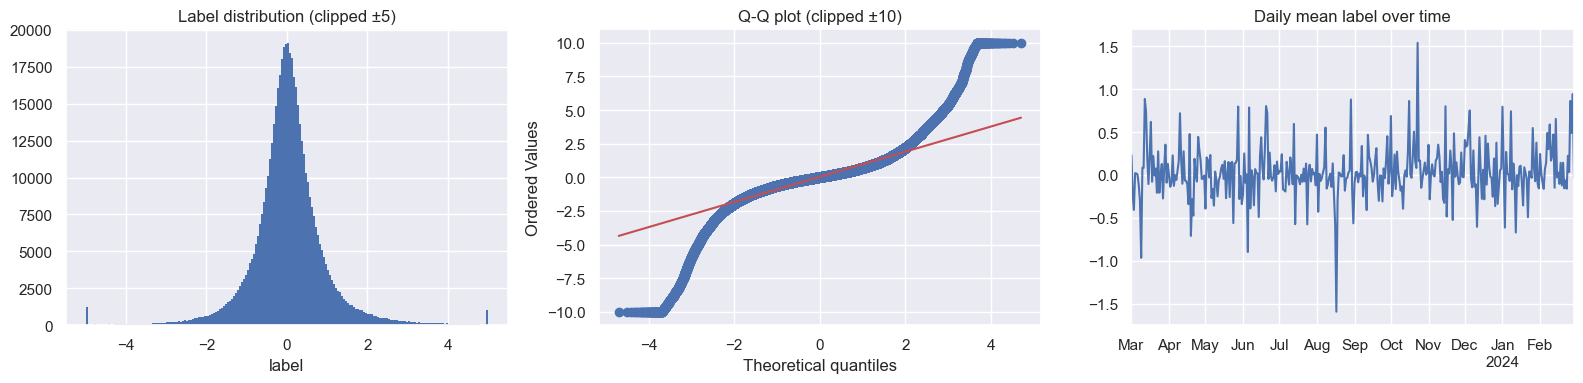

count    525886.000000
mean          0.036126
std           1.009915
min         -24.416615
25%          -0.381586
50%           0.016261
75%           0.434137
max          20.740270
Name: label, dtype: float64
% positive: 51.17%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram (clipped at ±5 to show body)
axes[0].hist(train['label'].clip(-5, 5), bins=200, edgecolor='none')
axes[0].set_title('Label distribution (clipped ±5)')
axes[0].set_xlabel('label')

# QQ-plot
from scipy import stats
stats.probplot(train['label'].clip(-10, 10), plot=axes[1])
axes[1].set_title('Q-Q plot (clipped ±10)')

# Rolling mean of label (daily)
train['label'].resample('D').mean().plot(ax=axes[2])
axes[2].set_title('Daily mean label over time')
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

print(train['label'].describe())
print(f"% positive: {(train['label'] > 0).mean()*100:.2f}%")

### 2. Market microstructure features (bid/ask/buy/sell/volume)

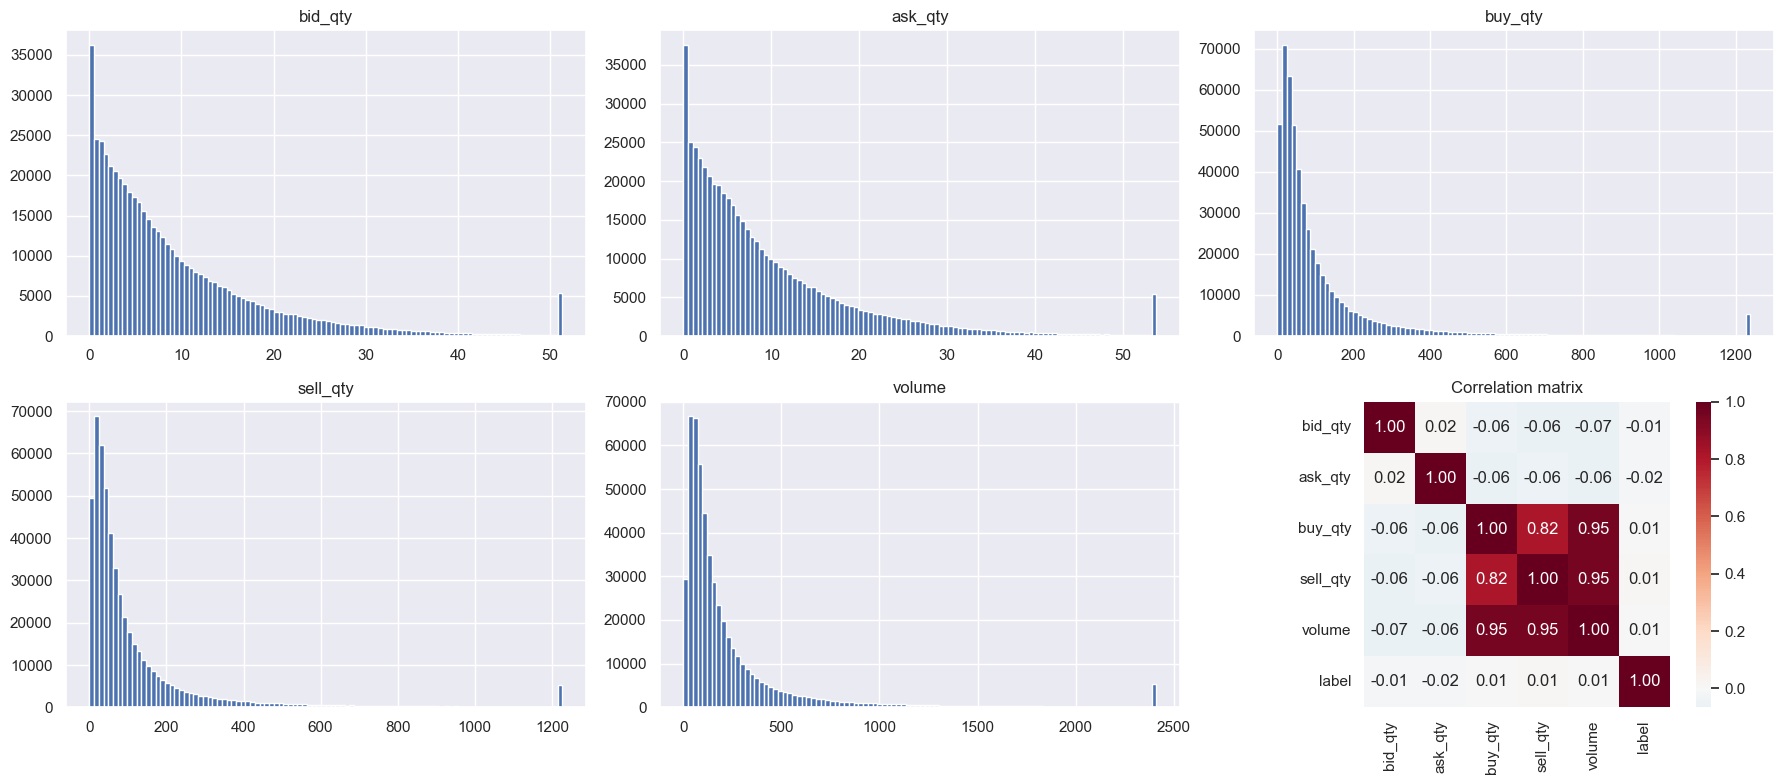

In [9]:
micro_cols = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(micro_cols):
    ax = axes[i // 3][i % 3]
    train[col].clip(upper=train[col].quantile(0.99)).hist(bins=100, ax=ax)
    ax.set_title(col)

# Correlation heatmap of microstructure + label
ax_corr = axes[1][2]
corr = train[micro_cols + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax_corr, cmap='RdBu_r', center=0, square=True)
ax_corr.set_title('Correlation matrix')

plt.tight_layout()
plt.show()

In [10]:
# Derived microstructure signals
train_micro = train[micro_cols].copy()
train_micro['order_imbalance'] = (train['buy_qty'] - train['sell_qty']) / (train['buy_qty'] + train['sell_qty'] + 1e-9)
train_micro['bid_ask_imbalance'] = (train['bid_qty'] - train['ask_qty']) / (train['bid_qty'] + train['ask_qty'] + 1e-9)
train_micro['label'] = train['label']

print("Correlation of derived signals with label:")
print(train_micro[['order_imbalance', 'bid_ask_imbalance', 'label']].corr()['label'].drop('label'))

Correlation of derived signals with label:
order_imbalance     -0.006079
bid_ask_imbalance    0.011018
Name: label, dtype: float64


### 3. Anonymized feature analysis (X1–X780)

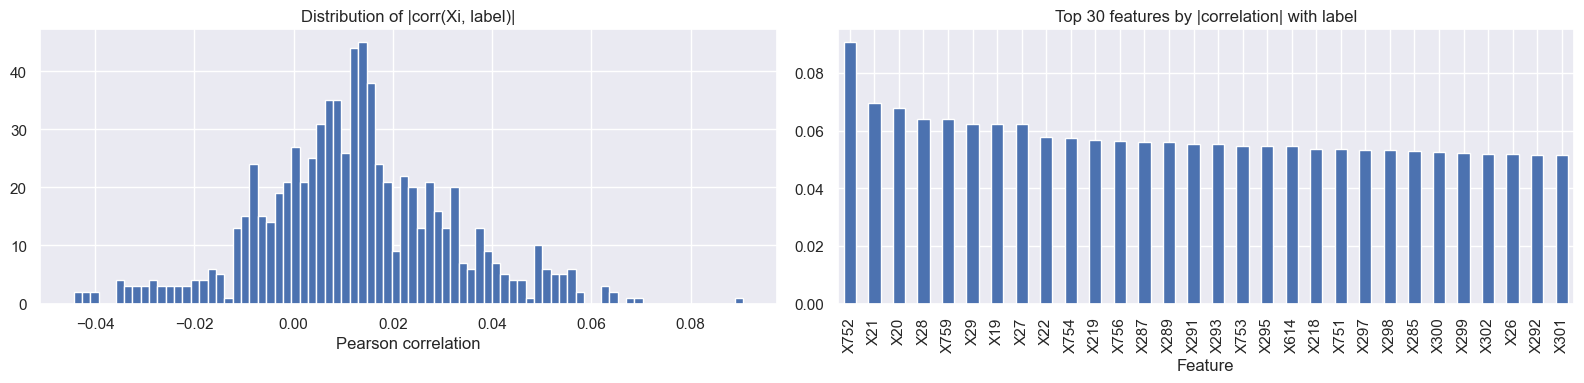


Features with |corr| > 0.1:  0
Features with |corr| > 0.05: 32

Top 10 most correlated features:
X752    0.090561
X21     0.069401
X20     0.067667
X28     0.064092
X759    0.064057
X29     0.062339
X19     0.062293
X27     0.062251
X22     0.057676
X754    0.057320
Name: corr_with_label, dtype: float64


In [11]:
x_cols = [c for c in train.columns if c.startswith('X')]

# Correlation of every X feature with label
feat_corr = train[x_cols].corrwith(train['label']).rename('corr_with_label')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

feat_corr.hist(bins=80, ax=axes[0])
axes[0].set_title('Distribution of |corr(Xi, label)|')
axes[0].set_xlabel('Pearson correlation')

feat_corr.abs().sort_values(ascending=False).head(30).plot.bar(ax=axes[1])
axes[1].set_title('Top 30 features by |correlation| with label')
axes[1].set_xlabel('Feature')

plt.tight_layout()
plt.show()

print(f"\nFeatures with |corr| > 0.1:  {(feat_corr.abs() > 0.1).sum()}")
print(f"Features with |corr| > 0.05: {(feat_corr.abs() > 0.05).sum()}")
print(f"\nTop 10 most correlated features:")
print(feat_corr.abs().sort_values(ascending=False).head(10))

X columns with any NaN:       0
X columns that are constant:  0


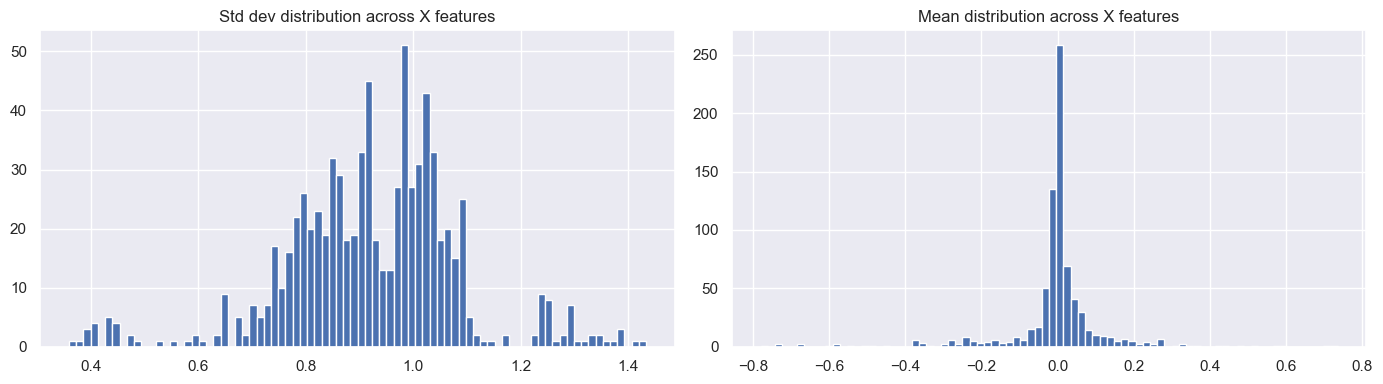

In [12]:
# Missing values and constant features in X columns
missing = train[x_cols].isnull().sum()
zero_std = (train[x_cols].std() < 1e-6).sum()
print(f"X columns with any NaN:       {(missing > 0).sum()}")
print(f"X columns that are constant:  {zero_std}")

# Value range overview (std distribution across features)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train[x_cols].std().hist(bins=80, ax=axes[0])
axes[0].set_title('Std dev distribution across X features')

train[x_cols].mean().hist(bins=80, ax=axes[1])
axes[1].set_title('Mean distribution across X features')

plt.tight_layout()
plt.show()

### 3.1 X-feature inter-correlation & redundancy

Correlation of each X with the *label* was covered in §3. Here we look at correlation *between* the X features themselves — i.e. how much redundancy / multicollinearity lives in the 780-dim feature block.

Feature pairs analysed: 303,810
  mean |r|:   0.1259
  median |r|: 0.0636
  pairs with |r| > 0.80: 2,238 (0.737%)
  pairs with |r| > 0.90: 1,112 (0.366%)
  pairs with |r| > 0.95: 459 (0.151%)
  pairs with |r| > 0.99: 112 (0.037%)


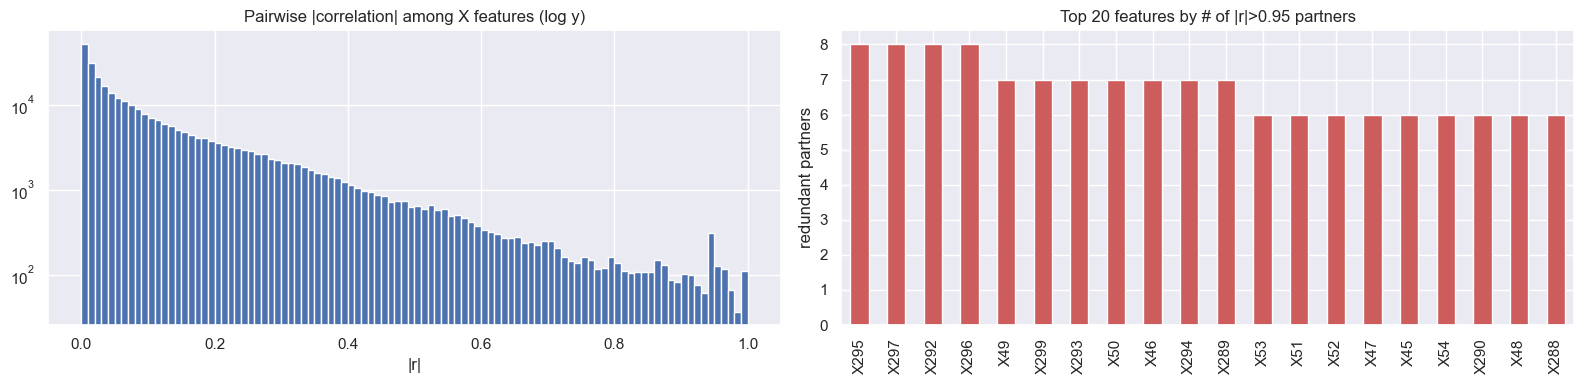


Top 25 most correlated feature pairs:
  X339   ~ X381   : 1.0000
  X333   ~ X375   : 1.0000
  X345   ~ X429   : 1.0000
  X345   ~ X387   : 1.0000
  X92    ~ X176   : 1.0000
  X339   ~ X423   : 1.0000
  X98    ~ X140   : 1.0000
  X98    ~ X182   : 1.0000
  X104   ~ X146   : 1.0000
  X351   ~ X393   : 1.0000
  X110   ~ X152   : 1.0000
  X327   ~ X411   : 1.0000
  X116   ~ X158   : 1.0000
  X327   ~ X369   : 1.0000
  X321   ~ X405   : 1.0000
  X321   ~ X363   : 1.0000
  X92    ~ X134   : 1.0000
  X357   ~ X399   : 1.0000
  X315   ~ X399   : 1.0000
  X387   ~ X429   : 1.0000
  X62    ~ X104   : 1.0000
  X62    ~ X146   : 1.0000
  X68    ~ X110   : 1.0000
  X68    ~ X152   : 1.0000
  X74    ~ X116   : 1.0000


In [13]:
import numpy as np
from collections import Counter

x_cols = [c for c in train.columns if c.startswith('X')]

# Pairwise correlation among X features (sample rows for speed)
x_corr = train[x_cols].sample(50_000, random_state=42).corr()

# Off-diagonal, upper-triangle |correlations|
mask = np.triu(np.ones(x_corr.shape, dtype=bool), k=1)
abs_corr = x_corr.where(mask).abs().stack()

print(f"Feature pairs analysed: {len(abs_corr):,}")
print(f"  mean |r|:   {abs_corr.mean():.4f}")
print(f"  median |r|: {abs_corr.median():.4f}")
for t in [0.8, 0.9, 0.95, 0.99]:
    c = int((abs_corr > t).sum())
    print(f"  pairs with |r| > {t:.2f}: {c:,} ({c / len(abs_corr) * 100:.3f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(abs_corr.values, bins=100)
axes[0].set_yscale('log')
axes[0].set_title('Pairwise |correlation| among X features (log y)')
axes[0].set_xlabel('|r|')

# Redundancy degree: how many partners each feature has at |r| > 0.95
high = abs_corr[abs_corr > 0.95]
if len(high):
    deg = Counter()
    for a, b in high.index:
        deg[a] += 1
        deg[b] += 1
    deg_series = pd.Series(deg).sort_values(ascending=False)
    deg_series.head(20).plot.bar(ax=axes[1], color='indianred')
    axes[1].set_title('Top 20 features by # of |r|>0.95 partners')
    axes[1].set_ylabel('redundant partners')
else:
    axes[1].text(0.5, 0.5, 'No pairs with |r| > 0.95', ha='center', va='center')
    axes[1].set_title('Redundancy (|r| > 0.95)')

plt.tight_layout()
plt.show()

print("\nTop 25 most correlated feature pairs:")
for (a, b), v in abs_corr.sort_values(ascending=False).head(25).items():
    print(f"  {a:6s} ~ {b:6s} : {v:.4f}")

### 3.2 Constant, near-constant & zero analysis

X features: 780   (std & zero_frac: full data | nunique & mode_frac: 100k sample)
  exactly constant (std == 0):          0
  near-constant    (std < 1e-6):        0
  near-constant    (mode_frac > 0.99):  0
  low-cardinality  (nunique <= 10):     0
  contains any exact zeros:             0
  mostly zero      (zero_frac > 0.50):  0


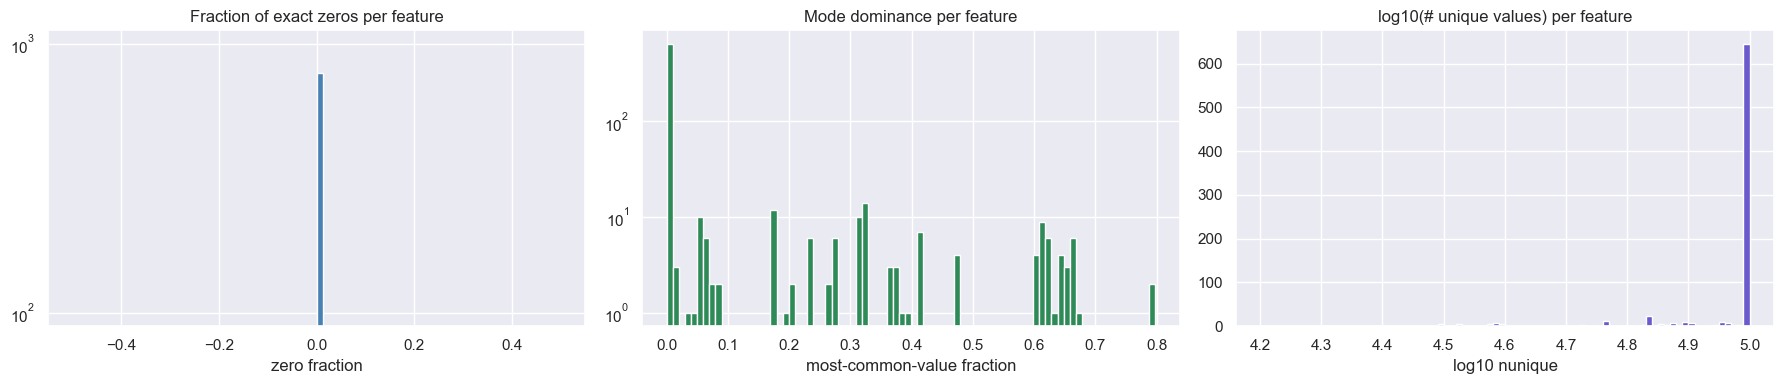


Most near-constant features (highest mode dominance):
         std  zero_frac  nunique  mode_frac
X745  0.8974        0.0    15907     0.7978
X744  0.9491        0.0    20117     0.7978
X661  1.0081        0.0    32824     0.6718
X665  1.0095        0.0    33226     0.6678
X669  1.0218        0.0    33500     0.6650
X677  1.0437        0.0    33518     0.6648
X673  1.0325        0.0    33542     0.6646
X685  1.0268        0.0    33601     0.6640
X681  1.0409        0.0    33727     0.6627
X393  0.9999        0.0    31267     0.6499

Most sparse features (highest zero fraction):
         std  zero_frac  nunique  mode_frac
X1    0.9121        0.0    99975     0.0001
X537  0.8880        0.0   100000     0.0000
X515  1.0408        0.0    90988     0.0530
X516  0.8688        0.0    91767     0.0737
X517  1.2940        0.0    99887     0.0006
X518  1.0064        0.0    93456     0.0510
X519  0.9383        0.0   100000     0.0000
X520  1.3317        0.0    99877     0.0007
X521  1.0286      

In [14]:
# Constant / near-constant / sparsity diagnostics on X features
# std & zero_frac on full data (vectorised); nunique & mode_frac on a 100k sample (speed)
samp = train[x_cols].sample(100_000, random_state=42)

diag = pd.DataFrame(index=x_cols)
diag['std']       = train[x_cols].std()
diag['zero_frac'] = (train[x_cols] == 0).mean()
diag['nunique']   = samp.nunique()
diag['mode_frac'] = samp.apply(lambda s: s.value_counts(normalize=True).iloc[0])

print(f"X features: {len(x_cols)}   (std & zero_frac: full data | nunique & mode_frac: 100k sample)")
print(f"  exactly constant (std == 0):          {(diag['std'] == 0).sum()}")
print(f"  near-constant    (std < 1e-6):        {(diag['std'] < 1e-6).sum()}")
print(f"  near-constant    (mode_frac > 0.99):  {(diag['mode_frac'] > 0.99).sum()}")
print(f"  low-cardinality  (nunique <= 10):     {(diag['nunique'] <= 10).sum()}")
print(f"  contains any exact zeros:             {(diag['zero_frac'] > 0).sum()}")
print(f"  mostly zero      (zero_frac > 0.50):  {(diag['zero_frac'] > 0.50).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(diag['zero_frac'], bins=80, color='steelblue')
axes[0].set_yscale('log')
axes[0].set_title('Fraction of exact zeros per feature')
axes[0].set_xlabel('zero fraction')

axes[1].hist(diag['mode_frac'], bins=80, color='seagreen')
axes[1].set_yscale('log')
axes[1].set_title('Mode dominance per feature')
axes[1].set_xlabel('most-common-value fraction')

axes[2].hist(np.log10(diag['nunique'].clip(lower=1)), bins=80, color='slateblue')
axes[2].set_title('log10(# unique values) per feature')
axes[2].set_xlabel('log10 nunique')

plt.tight_layout()
plt.show()

print("\nMost near-constant features (highest mode dominance):")
print(diag.sort_values('mode_frac', ascending=False).head(10).round(4).to_string())
print("\nMost sparse features (highest zero fraction):")
print(diag.sort_values('zero_frac', ascending=False).head(10).round(4).to_string())

### 3.3 Feature clustering → medoid representatives (complete linkage, |r| ≥ 0.6)

§3.1 showed the 780 X features are highly redundant. We cluster on correlation and keep one **representative** per cluster.

- **Distance** = `1 - |corr|`.
- **Complete linkage** cut at distance `1 - 0.6 = 0.4`. Complete linkage bounds a cluster's *largest* pairwise distance, so **every pair inside a cluster has |r| ≥ 0.6**.
- **Medoid** of each cluster = the member with the highest total |corr| to its clustermates (most central; min total distance). Singletons are their own medoid.

The medoids become `representative_features`, usable in place of the full X block downstream.

Original X features:           780
Clusters at |r| >= 0.4:        109
Representative features kept:  109  (14.0% of original)
Cluster size  - max: 24, mean: 7.2, singletons: 3
Among representatives - max |r|: 0.943, mean |r|: 0.094, pairs >0.4: 236


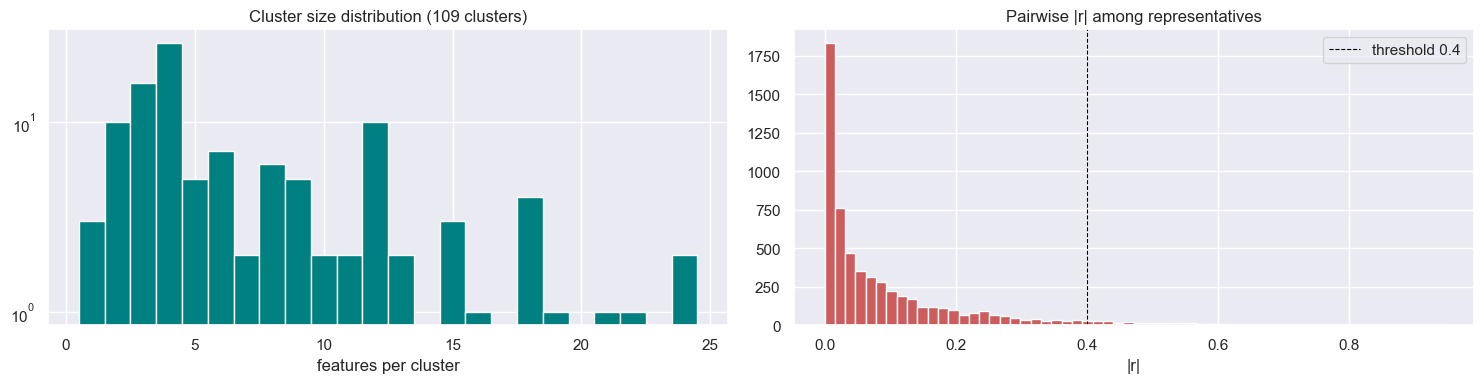


Largest clusters (medoid in [brackets]):
  cluster   4 (n=24) [X39]: X17, X25, X33, X34, X35, X36, X37, X38 ...
  cluster  32 (n=24) [X284]: X264, X272, X280, X281, X282, X283, X285, X286 ...
  cluster  69 (n=22) [X650]: X646, X647, X651, X654, X655, X678, X679, X682 ...
  cluster  42 (n=21) [X131]: X89, X95, X125, X133, X137, X139, X167, X169 ...
  cluster  23 (n=19) [X624]: X77, X83, X119, X121, X127, X151, X157, X161 ...
  cluster  48 (n=18) [X68]: X62, X74, X104, X110, X116, X146, X152, X158 ...
  cluster  45 (n=18) [X182]: X92, X98, X134, X140, X176, X217, X218, X219 ...
  cluster  35 (n=18) [X451]: X443, X444, X445, X450, X452, X457, X458, X459 ...
  cluster  72 (n=18) [X638]: X634, X635, X639, X642, X643, X690, X691, X694 ...
  cluster  57 (n=16) [X622]: X65, X71, X107, X113, X149, X155, X312, X318 ...

Saved `representative_features` (109 cols).


In [15]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import numpy as np

x_cols = [c for c in train.columns if c.startswith('X')]

# Correlation on a sample (consistent with 3.1)
corr     = train[x_cols].sample(50_000, random_state=42).corr()
abs_corr = corr.abs().fillna(0.0)

# Distance = 1 - |corr|; complete linkage bounds the cluster diameter, so cutting
# at distance (1 - threshold) guarantees every within-cluster pair has |r| >= threshold.
CORR_THRESHOLD = 0.4
dist = 1.0 - abs_corr.values
dist = (dist + dist.T) / 2.0            # enforce exact symmetry
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)

Z = linkage(condensed, method='complete')
cluster_labels = fcluster(Z, t=1.0 - CORR_THRESHOLD, criterion='distance')

clusters = {}
for feat, lab in zip(x_cols, cluster_labels):
    clusters.setdefault(lab, []).append(feat)

# Medoid = member with max total |corr| to clustermates (singletons -> themselves)
representatives, cluster_table = [], []
for lab, members in clusters.items():
    if len(members) == 1:
        medoid = members[0]
    else:
        sub = abs_corr.loc[members, members]
        medoid = (sub.sum(axis=1) - 1.0).idxmax()   # subtract self-corr (=1)
    representatives.append(medoid)
    cluster_table.append((lab, len(members), medoid, members))

representatives = sorted(representatives, key=lambda c: int(c[1:]))   # tidy: order by X-number

# Redundancy among the chosen representatives
rep_corr  = abs_corr.loc[representatives, representatives]
rmask     = np.triu(np.ones(rep_corr.shape, dtype=bool), k=1)
rep_pairs = rep_corr.where(rmask).stack()

sizes = pd.Series([len(m) for m in clusters.values()])
print(f"Original X features:           {len(x_cols)}")
print(f"Clusters at |r| >= {CORR_THRESHOLD}:        {len(clusters)}")
print(f"Representative features kept:  {len(representatives)}  "
      f"({len(representatives) / len(x_cols) * 100:.1f}% of original)")
print(f"Cluster size  - max: {sizes.max()}, mean: {sizes.mean():.1f}, singletons: {(sizes == 1).sum()}")
print(f"Among representatives - max |r|: {rep_pairs.max():.3f}, mean |r|: {rep_pairs.mean():.3f}, "
      f"pairs >{CORR_THRESHOLD}: {int((rep_pairs > CORR_THRESHOLD).sum())}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
axes[0].hist(sizes, bins=range(1, int(sizes.max()) + 2), color='teal', align='left')
axes[0].set_yscale('log')
axes[0].set_title(f'Cluster size distribution ({len(clusters)} clusters)')
axes[0].set_xlabel('features per cluster')

axes[1].hist(rep_pairs.values, bins=60, color='indianred')
axes[1].axvline(CORR_THRESHOLD, color='black', ls='--', lw=0.8, label=f'threshold {CORR_THRESHOLD}')
axes[1].set_title('Pairwise |r| among representatives')
axes[1].set_xlabel('|r|')
axes[1].legend()
plt.tight_layout()
plt.show()

print("\nLargest clusters (medoid in [brackets]):")
for lab, size, medoid, members in sorted(cluster_table, key=lambda x: -x[1])[:10]:
    others  = [m for m in members if m != medoid]
    preview = ", ".join(others[:8]) + (" ..." if len(others) > 8 else "")
    print(f"  cluster {lab:>3} (n={size:>2}) [{medoid}]: {preview}")

representative_features = representatives
print(f"\nSaved `representative_features` ({len(representative_features)} cols).")

### 3.4 Drop representatives weakly correlated with the target

From the §3.3 medoid `representative_features`, drop any whose absolute Pearson correlation with `label` is ≤ `0.01` — keep only representatives with a "weak but real" association (well above the ~0.0014 noise floor; the single strongest feature is only ≈0.09).

Representatives before:                109
|corr(rep, label)| <= 0.01  (dropped):  40
Representatives kept:                  69


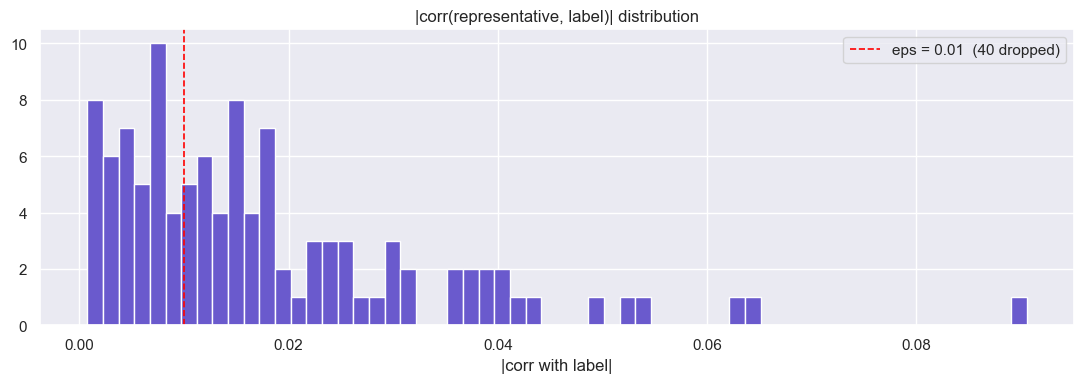


Strongest surviving representatives:
X752    0.09056
X759    0.06406
X27     0.06225
X614    0.05453
X298    0.05310
X30     0.04959
X284    0.04376
X652    0.04144
X758    0.04083
X131    0.04058

Final representative_features (69): ['X16', 'X27', 'X30', 'X39', 'X51', 'X63', 'X67', 'X68', 'X91', 'X105', 'X109', 'X123', 'X130', 'X131', 'X150', 'X174', 'X182', 'X186', 'X203', 'X216', 'X231', 'X269', 'X271', 'X274', 'X284', 'X298', 'X310', 'X313', 'X352', 'X353', 'X355', 'X376', 'X380', 'X398', 'X421', 'X442', 'X451', 'X460', 'X483', 'X486', 'X496', 'X500', 'X503', 'X506', 'X533', 'X534', 'X543', 'X570', 'X572', 'X580', 'X606', 'X608', 'X610', 'X614', 'X624', 'X652', 'X653', 'X661', 'X667', 'X709', 'X725', 'X737', 'X750', 'X752', 'X758', 'X759', 'X764', 'X768', 'X770']


In [16]:
# Drop medoid representatives weakly correlated with the target.
CORR_EPS = 0.01

assert 'representative_features' in globals(), "Run 3.3 first to build representative_features."

rep_corr = train[representative_features].corrwith(train['label']).abs().fillna(0.0)

drop = rep_corr[rep_corr <= CORR_EPS].index.tolist()
kept = rep_corr[rep_corr >  CORR_EPS].index.tolist()

before = len(representative_features)
representative_features = sorted(kept, key=lambda c: int(c[1:]))

print(f"Representatives before:                {before}")
print(f"|corr(rep, label)| <= {CORR_EPS:g}  (dropped):  {len(drop)}")
print(f"Representatives kept:                  {len(representative_features)}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(rep_corr.values, bins=60, color='slateblue')
ax.axvline(CORR_EPS, color='red', ls='--', lw=1.2,
           label=f'eps = {CORR_EPS:g}  ({len(drop)} dropped)')
ax.set_title('|corr(representative, label)| distribution')
ax.set_xlabel('|corr with label|')
ax.legend()
plt.tight_layout()
plt.show()

print("\nStrongest surviving representatives:")
print(rep_corr.loc[kept].sort_values(ascending=False).head(10).round(5).to_string())
print(f"\nFinal representative_features ({len(representative_features)}): {representative_features}")

In [17]:
FEATURES = representative_features + ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']

### 4. Base Model

In [18]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from scipy.stats import pearsonr
import shap

FOLDS = 5
kf = KFold(n_splits=FOLDS)

oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

xgb_params = {
    "tree_method": "hist",
    "colsample_bylevel": 0.4778015829774066,
    "colsample_bynode": 0.362764358742407,
    "colsample_bytree": 0.7107423488010493,
    "gamma": 1.7094857725240398,
    "learning_rate": 0.02213323588455387,
    "max_depth": 20,
    "max_leaves": 12,
    "min_child_weight": 16,
    "n_estimators": 1667,
    "n_jobs": -1,
    "random_state": 42,
    "reg_alpha": 39.352415706891264,
    "reg_lambda": 75.44843704068275,
    "subsample": 0.06566669853471274,
    "verbosity": 0
}

for i, (train_idx, valid_idx) in enumerate(kf.split(train)):
    print("#" * 25)
    print(f"### Fold {i + 1}")
    print("#" * 25)

    X_train = train.iloc[train_idx][FEATURES]
    y_train = train.iloc[train_idx]["label"]
    X_valid = train.iloc[valid_idx][FEATURES]
    y_valid = train.iloc[valid_idx]["label"]
    X_test = test[FEATURES]

    model = XGBRegressor(**xgb_params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=200
    )

    oof_preds[valid_idx] = model.predict(X_valid)
    test_preds += model.predict(X_test)

pearson_score = pearsonr(train["label"], oof_preds)[0]
print("Final Pearson Correlation = ", pearson_score)

test_preds /= FOLDS

#########################
### Fold 1
#########################
[0]	validation_0-rmse:1.00926
[200]	validation_0-rmse:0.99692
[400]	validation_0-rmse:0.99513
[600]	validation_0-rmse:0.99618
[800]	validation_0-rmse:0.99628
[1000]	validation_0-rmse:0.99742
[1200]	validation_0-rmse:0.99889
[1400]	validation_0-rmse:1.00052
[1600]	validation_0-rmse:1.00307
[1666]	validation_0-rmse:1.00347
#########################
### Fold 2
#########################
[0]	validation_0-rmse:0.94913
[200]	validation_0-rmse:0.94251
[400]	validation_0-rmse:0.94130
[600]	validation_0-rmse:0.94163
[800]	validation_0-rmse:0.94235
[1000]	validation_0-rmse:0.94342
[1200]	validation_0-rmse:0.94442
[1400]	validation_0-rmse:0.94531
[1600]	validation_0-rmse:0.94644
[1666]	validation_0-rmse:0.94686
#########################
### Fold 3
#########################
[0]	validation_0-rmse:1.02349
[200]	validation_0-rmse:1.01995
[400]	validation_0-rmse:1.01834
[600]	validation_0-rmse:1.01855
[800]	validation_0-rmse:1.01879
[1000]	

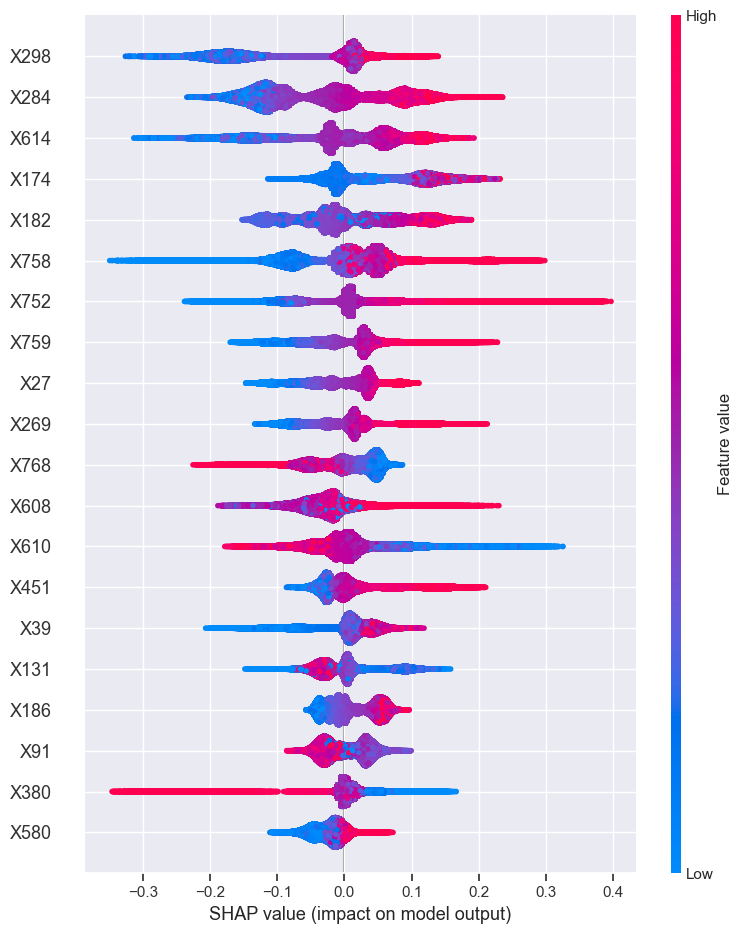

In [19]:
explainer = shap.TreeExplainer(model, feature_perturbation="tree_path_dependent", model_output="raw")
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)


In [20]:
sample_submission["prediction"] = test_preds
sample_submission.to_csv("submission.csv", index=False)
sample_submission.head()

,ID,prediction
0,1,-0.046365
1,2,0.236876
2,3,-0.384090
3,4,-0.235874
4,5,-0.100384


### 5. Improved model — purged group time-series CV

§4's base model uses plain `KFold`, which **leaks** on this autocorrelated (AR-1, φ≈0.98) series: folds train on the future and there's no purge at the fold boundaries, so the OOF Pearson is optimistic and won't track the leaderboard. §5 keeps the same OOF + test-bagging structure but fixes it:

- **`KFold` → `PurgedGroupTimeSeriesSplit(gap=1)`**: 6 groups (~2 months each), purge 1 group on **each side** of the test fold (≈2 months before & after).
- **`grow_policy="lossguide"`** so `max_leaves=12` actually binds (ambiguous under the default depthwise growth with `max_depth=20`).
- **per-fold + overall OOF Pearson** (the competition metric); NaN-safe OOF (the purged split still covers every row exactly once).
- reuses the `FEATURES` you defined above (representatives + microstructure).

> Heads-up: the raw microstructure features (`volume`, `buy_qty`, …) have a large train→test shift — worth normalizing if they hurt the LB.

In [21]:
from xgboost import XGBRegressor
from scipy.stats import pearsonr

# Use the FEATURES defined above (representatives + microstructure); fallback if absent
if 'FEATURES' not in globals():
    _micro = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']
    FEATURES = (representative_features + _micro) if 'representative_features' in globals() \
               else [c for c in train.columns if c.startswith('X')]
print(f"Modeling on {len(FEATURES)} features")

# 6 time-ordered groups (~2 months each)
groups = np.asarray(((train.index.year - 2023) * 12 + (train.index.month - 3)) // 2)

class PurgedGroupTimeSeriesSplit:
    """Each group is the test fold once; with gap=g, the g groups BEFORE and AFTER
    the test group are purged from training (kills AR(1) boundary leakage)."""
    def __init__(self, gap=1):
        self.gap = gap
    def split(self, groups):
        for k in np.sort(np.unique(groups)):
            test = np.where(groups == k)[0]
            trn  = np.where(np.abs(groups - k) > self.gap)[0]
            yield trn, test, int(k)

xgb_params = {
    "tree_method": "hist",
    "grow_policy": "lossguide",      # so max_leaves=12 actually binds
    "colsample_bylevel": 0.4778015829774066,
    "colsample_bynode": 0.362764358742407,
    "colsample_bytree": 0.7107423488010493,
    "gamma": 1.7094857725240398,
    "learning_rate": 0.02213323588455387,
    "max_depth": 20,
    "max_leaves": 12,
    "min_child_weight": 16,
    "n_estimators": 1667,
    "n_jobs": -1,
    "random_state": 42,
    "reg_alpha": 39.352415706891264,
    "reg_lambda": 75.44843704068275,
    "subsample": 0.06566669853471274,
    "verbosity": 0,
}

X_all, y_all = train[FEATURES], train["label"]
X_test       = test[FEATURES]

oof_preds   = np.full(len(train), np.nan)
test_preds  = np.zeros(len(test))
fold_scores = []

for i, (train_idx, valid_idx, k) in enumerate(PurgedGroupTimeSeriesSplit(gap=1).split(groups)):
    print("#" * 25, f"Fold {i + 1} (test G{k})")
    model = XGBRegressor(**xgb_params)
    model.fit(X_all.iloc[train_idx], y_all.iloc[train_idx])

    valid_pred = model.predict(X_all.iloc[valid_idx])
    oof_preds[valid_idx] = valid_pred
    test_preds += model.predict(X_test)

    sc = pearsonr(y_all.iloc[valid_idx], valid_pred)[0]
    fold_scores.append(sc)
    print(f"   train groups {sorted(int(g) for g in set(groups[train_idx]))}, "
          f"n_train={len(train_idx):,}, n_valid={len(valid_idx):,}, valid Pearson={sc:+.4f}")

n_folds = len(fold_scores)
test_preds /= n_folds

mask = ~np.isnan(oof_preds)          # purged group split covers every row exactly once
oof_pearson = pearsonr(y_all[mask], oof_preds[mask])[0]
print(f"\nOOF coverage: {mask.sum():,}/{len(oof_preds):,}")
print(f"Per-fold Pearson : {[round(s, 4) for s in fold_scores]}")
print(f"Mean fold Pearson: {np.mean(fold_scores):+.4f}")
print(f"OOF Pearson (purged) = {oof_pearson:.4f}")

# ---- submission (same style as the base model) ----
sample_submission["prediction"] = test_preds
sample_submission.to_csv("submission2.csv", index=False)
print("\nsubmission2.csv:", sample_submission.shape)
print(sample_submission.head().to_string(index=False))

Modeling on 74 features
######################### Fold 1 (test G0)
   train groups [2, 3, 4, 5], n_train=350,358, n_valid=87,690, valid Pearson=+0.1173
######################### Fold 2 (test G1)
   train groups [3, 4, 5], n_train=261,428, n_valid=87,838, valid Pearson=+0.0649
######################### Fold 3 (test G2)
   train groups [0, 4, 5], n_train=261,627, n_valid=88,930, valid Pearson=+0.1023
######################### Fold 4 (test G3)
   train groups [0, 1, 5], n_train=261,747, n_valid=87,491, valid Pearson=+0.1227
######################### Fold 5 (test G4)
   train groups [0, 1, 2], n_train=264,458, n_valid=87,718, valid Pearson=+0.1179
######################### Fold 6 (test G5)
   train groups [0, 1, 2, 3], n_train=351,949, n_valid=86,219, valid Pearson=+0.0812

OOF coverage: 525,886/525,886
Per-fold Pearson : [np.float64(0.1173), np.float64(0.0649), np.float64(0.1023), np.float64(0.1227), np.float64(0.1179), np.float64(0.0812)]
Mean fold Pearson: +0.1011
OOF Pearson (purged) =

### 6. Linear baseline — Ridge regression

Same purged CV / `FEATURES` / OOF + test-bagging as §5, so the score is **directly comparable** to the XGB. Ridge needs:
- **scaled inputs** — `StandardScaler` fit *per fold* (no leakage). `RobustScaler` is unstable here (several features have ~0 IQR → division blow-up), so use `StandardScaler`.
- **L2 strength `alpha`** — auto-selected per fold by `RidgeCV` (efficient leave-one-out).

Keeps `ridge_oof` / `ridge_test` around so the linear and GBT predictions can be blended later.

In [22]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import pearsonr

# same FEATURES + groups + splitter as §5
if 'FEATURES' not in globals():
    _micro = ['bid_qty', 'ask_qty', 'buy_qty', 'sell_qty', 'volume']
    FEATURES = (representative_features + _micro) if 'representative_features' in globals() \
               else [c for c in train.columns if c.startswith('X')]
groups = np.asarray(((train.index.year - 2023) * 12 + (train.index.month - 3)) // 2)
if 'PurgedGroupTimeSeriesSplit' not in globals():
    class PurgedGroupTimeSeriesSplit:
        def __init__(self, gap=1):
            self.gap = gap
        def split(self, groups):
            for k in np.sort(np.unique(groups)):
                yield np.where(np.abs(groups - k) > self.gap)[0], np.where(groups == k)[0], int(k)

X_all, y_all = train[FEATURES], train["label"]
X_test       = test[FEATURES]
alphas = np.logspace(-1, 6, 15)

ridge_oof   = np.full(len(train), np.nan)
ridge_test  = np.zeros(len(test))
fold_scores, chosen_alphas = [], []

for i, (tr_idx, va_idx, k) in enumerate(PurgedGroupTimeSeriesSplit(gap=1).split(groups)):
    model = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas))
    model.fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])

    valid_pred = model.predict(X_all.iloc[va_idx])
    ridge_oof[va_idx] = valid_pred
    ridge_test += model.predict(X_test)

    a  = model[-1].alpha_
    sc = pearsonr(y_all.iloc[va_idx], valid_pred)[0]
    fold_scores.append(sc); chosen_alphas.append(a)
    print(f"Fold {i + 1} (test G{k}): alpha={a:.4g}, valid Pearson={sc:+.4f}")

ridge_test /= len(fold_scores)
mask = ~np.isnan(ridge_oof)
ridge_oof_pearson = pearsonr(y_all[mask], ridge_oof[mask])[0]
print(f"\nChosen alphas    : {[round(a, 1) for a in chosen_alphas]}")
print(f"Per-fold Pearson : {[round(s, 4) for s in fold_scores]}")
print(f"Mean fold Pearson: {np.mean(fold_scores):+.4f}")
print(f"Ridge OOF Pearson (purged) = {ridge_oof_pearson:.4f}")

# linear-model submission (kept separate from the XGB one)
ridge_submission = sample_submission.copy()
ridge_submission["prediction"] = ridge_test
ridge_submission.to_csv("submission_ridge.csv", index=False)
print("\nsubmission_ridge.csv:", ridge_submission.shape)

Fold 1 (test G0): alpha=1000, valid Pearson=+0.1025
Fold 2 (test G1): alpha=1000, valid Pearson=+0.1043
Fold 3 (test G2): alpha=1000, valid Pearson=+0.0437
Fold 4 (test G3): alpha=1000, valid Pearson=+0.1115
Fold 5 (test G4): alpha=316.2, valid Pearson=+0.1313
Fold 6 (test G5): alpha=1000, valid Pearson=+0.0798

Chosen alphas    : [np.float64(1000.0), np.float64(1000.0), np.float64(1000.0), np.float64(1000.0), np.float64(316.2), np.float64(1000.0)]
Per-fold Pearson : [np.float64(0.1025), np.float64(0.1043), np.float64(0.0437), np.float64(0.1115), np.float64(0.1313), np.float64(0.0798)]
Mean fold Pearson: +0.0955
Ridge OOF Pearson (purged) = 0.0940

submission_ridge.csv: (538150, 2)
